# Prediccion y ajuste de modelos

**Proyecto:** Colombia EVA

**Materia:** Programacion Avanzada  
**Profesor:** Jaime Alberto Vergara Tejada  
**Estudiante:** Diego Alejandro Rios Vasquez  
**Correo:** diego.rios958@pascualbravo.edu.co

## Objetivo del analisis de datos

El proposito principal de este trabajo es analizar los datos agropecuarios del dataset Colombia EVA para entender su estructura, calidad, senales predictivas y limites metodologicos antes de cualquier decision de entrenamiento. Busco identificar que variables realmente aportan informacion, como afecta la representacion de categorias de alta cardinalidad, que impacto tiene la jerarquia agricola y como el desbalance de clases condiciona la evaluacion.


## Alcance del Desarrollo

1. Analizo el problema y la pertinencia de la variable objetivo.
2. Comparo escenarios con y sin variables productivas para medir aporte informativo.
3. Comparo estrategias de encoding categorico (`label/ordinal` vs `one-hot`).
4. Evalúo reduccion de dimensionalidad e importancia de variables.
5. Analizo el efecto de la jerarquia de variables de cultivo.
6. Comparo metricas (`accuracy` vs `f1_macro`) bajo desbalance de clases.
7. Ajusto hiperparametros y verifico la estabilidad de resultados.

## 0. Definicion formal del problema y criterio de exito

Este trabajo corresponde a un ejercicio de **clasificacion multiclase**. La variable objetivo es `ciclo_de_cultivo`, que representa categorias discretas y no una magnitud continua; por lo tanto, no se trata de un problema de regresion.

La pregunta tecnica que respondo es: **que tan bien puedo diferenciar las clases de `ciclo_de_cultivo` a partir de variables territoriales, productivas y categoricas, bajo decisiones de preprocesamiento justificadas**.

Criterio principal de evaluacion:
- Tomo `f1_macro` como metrica principal porque pondera todas las clases por igual y evita una lectura optimista cuando existe desbalance.
- Uso `accuracy` como metrica complementaria para comparar rendimiento global.


In [1]:
# Instalacion defensiva de dependencias
import importlib.util
import subprocess
import sys

# Mapeo explicito paquete -> modulo importable para evitar falsos faltantes
required = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scikit-learn': 'sklearn'
}

missing = [pkg for pkg, module_name in required.items() if importlib.util.find_spec(module_name) is None]

if missing:
    print(f'Instalando paquetes faltantes: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)

print('Dependencias listas.')

Dependencias listas.


## Dependencias del proyecto

En esta seccion separo las dependencias para dejar claro que herramientas uso y por que las incluyo en el flujo de trabajo.

- `pandas`: carga, limpieza, transformacion tabular y reportes de resultados.
- `numpy`: operaciones numericas, manejo de `NaN` y apoyo en transformaciones.
- `matplotlib`: graficos base para comparaciones y visualizacion de metricas.
- `seaborn`: visualizaciones estadisticas para barras, dispersion y matrices de confusion.
- `scikit-learn`: construccion de pipelines, preprocesamiento, modelos de clasificacion, seleccion/reduccion de variables y evaluacion.

In [2]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
TARGET_COLUMN = 'ciclo_de_cultivo'

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

## 1. Carga y estandarizacion de datos

En esta seccion cargo el dataset EVA desde el CSV local y aplico una homologacion de nombres de columnas para unificar variantes de escritura (acentos, mayusculas, espacios y caracteres especiales). Despues convierto columnas candidatas a formato numerico y limpio inconsistencias basicas en variables categoricas (espacios y formato), con el fin de dejar una base estable para el analisis y el modelado.

In [3]:
# Homologo encabezados del EVA para evitar errores por acentos, espacios o variantes de nombre
# y dejar una base consistente para todo el pipeline de modelado.
def normalize_header(text):
    s = str(text).replace('\n', ' ').strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def standardize_eva_columns(df_input):
    target_map = {
        'cod dep': 'c_d_dep',
        'departamento': 'departamento',
        'cod mun': 'c_d_mun',
        'municipio': 'municipio',
        'grupo de cultivo': 'grupo_de_cultivo',
        'subgrupo de cultivo': 'subgrupo_de_cultivo',
        'cultivo': 'cultivo',
        'desagregacion regional y o sistema productivo': 'desagregaci_n_regional_y',
        'ano': 'a_o',
        'periodo': 'periodo',
        'area sembrada ha': 'rea_sembrada_ha',
        'area cosechada ha': 'rea_cosechada_ha',
        'produccion t': 'producci_n_t',
        'rendimiento t ha': 'rendimiento_t_ha',
        'estado fisico produccion': 'estado_fisico_produccion',
        'nombre cientifico': 'nombre_cientifico',
        'ciclo de cultivo': 'ciclo_de_cultivo'
    }

    rename_map = {}
    for col in df_input.columns:
        normalized = normalize_header(col)
        if normalized in target_map:
            rename_map[col] = target_map[normalized]

    return df_input.rename(columns=rename_map).copy(), rename_map

csv_path = Path('data') / 'Evaluaciones_Agropecuarias_Municipales_EVA.csv'

if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el CSV en: {csv_path}')

df_raw = pd.read_csv(csv_path)
df, renamed = standardize_eva_columns(df_raw)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print(f'Columnas homologadas: {len(renamed)}')
display(df.head())

Filas: 206,068 | Columnas: 17
Columnas homologadas: 17


,c_d_dep,departamento,c_d_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregaci_n_regional_y,a_o,periodo,rea_sembrada_ha,rea_cosechada_ha,producci_n_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,"1,440",18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,"54,405",LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,"54,518",PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


In [4]:
# Estandarizo tipos y formatos para que el modelado no dependa de ruido de parsing
# (comas de miles, espacios y strings inconsistentes).
expected_numeric = [
    'c_d_dep', 'c_d_mun', 'a_o',
    'rea_sembrada_ha', 'rea_cosechada_ha',
    'producci_n_t', 'rendimiento_t_ha'
 ]

for c in expected_numeric:
    if c in df.columns:
        # El CSV mezcla separadores de miles; sin limpiar esto, se inducen nulos falsos.
        cleaned = df[c].astype(str).str.replace(',', '', regex=False).str.strip()
        df[c] = pd.to_numeric(cleaned, errors='coerce')

# Normalizo categóricas para reducir cardinalidad artificial por espacios/formato.
for c in df.select_dtypes(include=['object', 'string']).columns:
    s = df[c].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
    df[c] = s.where(df[c].notna(), np.nan)

print('Tipos de datos principales:')
display(df.dtypes.value_counts())

print('Distribucion de clases objetivo:')
display(df[TARGET_COLUMN].value_counts(dropna=False).to_frame('conteo'))

print('Nulos en variables numericas esperadas (%):')
null_pct = df[[c for c in expected_numeric if c in df.columns]].isna().mean().mul(100).round(2)
display(null_pct.to_frame('porcentaje_nulos'))

Tipos de datos principales:


str        10
int64       6
float64     1
Name: count, dtype: int64

Distribucion de clases objetivo:


,conteo
ciclo_de_cultivo,
TRANSITORIO,108943
PERMANENTE,82643
ANUAL,14482


Nulos en variables numericas esperadas (%):


,porcentaje_nulos
c_d_dep,0.00
c_d_mun,0.00
a_o,0.00
rea_sembrada_ha,0.00
rea_cosechada_ha,0.00
producci_n_t,0.00
rendimiento_t_ha,1.67


### 1.1 Preparacion de datos: diagnostico de faltantes, valores imposibles y valores extremos

Con base en la actividad anterior (EDA), en esta seccion hago el diagnostico formal dentro del notebook de modelado para dejar trazable la preparacion de datos.

Criterios que aplico:
- **Faltantes:** cuantifico porcentaje por variable para definir prioridad de tratamiento.
- **Imposibles:** en variables productivas (`area`, `produccion`, `rendimiento`) marco como imposibles los valores negativos y los convierto a nulos para imputacion posterior.
- **Extremos:** detecto outliers con regla IQR por variable numerica para dimensionar su impacto antes de entrenar.

In [5]:
# Diagnostico y tratamiento de calidad antes de modelar:
# 1) faltantes, 2) imposibles, 3) extremos.
quality_df = df.copy()

# 1) Faltantes por variable
missing_report = (
    quality_df.isna().mean().mul(100).round(2)
    .sort_values(ascending=False)
    .to_frame('porcentaje_faltante')
)
print('Top faltantes (%):')
display(missing_report.head(10))

# 2) Valores imposibles: negativos en variables productivas
productive_cols = ['rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']
impossible_rows = []
for col in productive_cols:
    if col in quality_df.columns:
        n_impossible = int((quality_df[col] < 0).sum())
        if n_impossible > 0:
            impossible_rows.append({'variable': col, 'imposibles_negativos': n_impossible})
            quality_df.loc[quality_df[col] < 0, col] = np.nan

impossible_report = pd.DataFrame(impossible_rows) if impossible_rows else pd.DataFrame(columns=['variable', 'imposibles_negativos'])
print('Valores imposibles detectados:')
display(impossible_report if not impossible_report.empty else pd.DataFrame([{'variable': 'ninguna', 'imposibles_negativos': 0}]))

# 3) Outliers por IQR para dimensionar impacto de colas
numeric_cols_q = quality_df.select_dtypes(include=[np.number]).columns.tolist()
outlier_rows = []
for col in numeric_cols_q:
    s = quality_df[col].dropna()
    if len(s) < 5:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((quality_df[col] < lb) | (quality_df[col] > ub)).sum())
    pct_out = round((n_out / len(quality_df)) * 100, 2)
    outlier_rows.append({'variable': col, 'outliers_iqr': n_out, 'porcentaje_outliers': pct_out})

outlier_report = pd.DataFrame(outlier_rows).sort_values('porcentaje_outliers', ascending=False)
print('Top outliers por IQR (%):')
display(outlier_report.head(10))

# Winsorizacion suave p1-p99 en variables productivas para estabilizar entrenamiento
winsor_rows = []
for col in productive_cols:
    if col in quality_df.columns:
        s = quality_df[col].dropna()
        if len(s) < 10:
            continue
        p01, p99 = s.quantile(0.01), s.quantile(0.99)
        before_min, before_max = float(s.min()), float(s.max())
        quality_df[col] = quality_df[col].clip(lower=p01, upper=p99)
        s2 = quality_df[col].dropna()
        after_min, after_max = float(s2.min()), float(s2.max())
        winsor_rows.append({
            'variable': col,
            'min_antes': round(before_min, 4),
            'max_antes': round(before_max, 4),
            'min_despues': round(after_min, 4),
            'max_despues': round(after_max, 4)
        })

winsor_report = pd.DataFrame(winsor_rows)
print('Resumen de winsorizacion (p1-p99) en variables productivas:')
display(winsor_report if not winsor_report.empty else pd.DataFrame([{'variable': 'sin cambios'}]))

# Dejo la version tratada como base unica para evitar drift entre secciones
df = quality_df.copy()

Top faltantes (%):


,porcentaje_faltante
rendimiento_t_ha,1.67
nombre_cientifico,1.39
c_d_dep,0.00
departamento,0.00
c_d_mun,0.00
subgrupo_de_cultivo,0.00
cultivo,0.00
municipio,0.00
grupo_de_cultivo,0.00
a_o,0.00


Valores imposibles detectados:


,variable,imposibles_negativos
0,ninguna,0


Top outliers por IQR (%):


,variable,outliers_iqr,porcentaje_outliers
3,rea_sembrada_ha,30154,14.63
4,rea_cosechada_ha,29763,14.44
5,producci_n_t,29598,14.36
6,rendimiento_t_ha,11324,5.50
2,a_o,0,0.00
0,c_d_dep,0,0.00
1,c_d_mun,0,0.00


Resumen de winsorizacion (p1-p99) en variables productivas:


,variable,min_antes,max_antes,min_despues,max_despues
0,rea_sembrada_ha,0.00,47403.0,1.0,4601.33
1,rea_cosechada_ha,0.00,38600.0,0.0,4000.00
2,producci_n_t,0.00,4546116.0,0.0,28000.00
3,rendimiento_t_ha,0.03,246.0,0.4,90.00


### Cierre de preparacion de datos

Despues de ejecutar este bloque, la base de modelado queda coherente y estable: cuantifiqué faltantes, convertí valores imposibles en nulos para tratarlos de forma consistente y apliqué winsorizacion suave en variables productivas para reducir el efecto de colas extremas sin destruir la estructura del dato. Con esto evito que el rendimiento de los modelos dependa de errores de calidad obvios y dejo el preprocesamiento alineado con una evaluacion justa entre escenarios.

## 2. Utilidades para experimentos

Aqui defino funciones reutilizables para construir conjuntos de variables, controlar categorias de alta cardinalidad, crear pipelines de preprocesamiento y evaluar modelos con las mismas metricas. Esta capa evita duplicar codigo, reduce errores y permite que las comparaciones entre experimentos sean justas y trazables.

In [6]:
# Utilidades comunes para que cada experimento sea comparable y reproducible.
productive_vars = [
    'rea_sembrada_ha',
    'rea_cosechada_ha',
    'producci_n_t',
    'rendimiento_t_ha'
]

hierarchy_cols = ['grupo_de_cultivo', 'subgrupo_de_cultivo', 'cultivo']

def group_rare_categories(df_input, cat_cols, top_n=25, rare_label='OTROS'):
    # Agrupo categorias raras para evitar que casos muy infrecuentes dominen el ajuste.
    df_out = df_input.copy()
    for c in cat_cols:
        if c not in df_out.columns:
            continue
        vc = df_out[c].value_counts(dropna=True)
        top_values = set(vc.head(top_n).index)
        df_out[c] = df_out[c].where(df_out[c].isin(top_values), rare_label)
    return df_out

def make_feature_set(df_input, use_productive=True, hierarchy_mode='full'):
    data = df_input.copy()

    if TARGET_COLUMN not in data.columns:
        raise ValueError(f'No existe la columna objetivo: {TARGET_COLUMN}')

    # Elimina filas sin objetivo para no sesgar métricas por imputación de la etiqueta.
    data = data.dropna(subset=[TARGET_COLUMN]).copy()

    drop_cols = []
    if not use_productive:
        drop_cols.extend([c for c in productive_vars if c in data.columns])

    if hierarchy_mode == 'grupo':
        drop_cols.extend([c for c in ['subgrupo_de_cultivo', 'cultivo'] if c in data.columns])
    elif hierarchy_mode == 'subgrupo':
        drop_cols.extend([c for c in ['grupo_de_cultivo', 'cultivo'] if c in data.columns])
    elif hierarchy_mode == 'full':
        pass
    else:
        raise ValueError('hierarchy_mode debe ser full, grupo o subgrupo')

    data = data.drop(columns=drop_cols, errors='ignore')

    y = data[TARGET_COLUMN].copy()
    X = data.drop(columns=[TARGET_COLUMN])

    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

    return X, y, numeric_cols, categorical_cols

def make_preprocessor(numeric_cols, categorical_cols, encoding='onehot'):
    num_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    if encoding == 'onehot':
        cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    elif encoding == 'label':
        cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    else:
        raise ValueError('encoding debe ser onehot o label')

    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', cat_encoder)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_cols),
            ('cat', cat_pipe, categorical_cols)
        ],
        remainder='drop'
    )
    return preprocessor

def evaluate_pipeline(name, X, y, preprocessor, model):
    # Misma estrategia de split para garantizar comparaciones justas entre escenarios.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro', zero_division=0)

    return {
        'experimento': name,
        'accuracy': acc,
        'f1_macro': f1m,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'pipeline': pipe,
        'y_test': y_test,
        'y_pred': pred
    }

## 3. Tarea 1 - Todas las variables vs sin productivas + encoding

En esta tarea pruebo cuatro escenarios:
- Todas las variables + One-Hot.
- Todas las variables + Label/Ordinal.
- Sin variables productivas + One-Hot.
- Sin variables productivas + Label/Ordinal.

In [ ]:
# Tarea 1: comparo impacto de variables productivas y tipo de encoding.
rf_model = RandomForestClassifier(
    n_estimators=350,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

results_task1 = []

for use_prod in [True, False]:
    X, y, num_cols, cat_cols = make_feature_set(df, use_productive=use_prod, hierarchy_mode='full')

    # Evito sobrecargar cardinalidad con categorias extremadamente raras.
    X = group_rare_categories(X, cat_cols, top_n=30, rare_label='OTROS')

    for enc in ['onehot', 'label']:
        pre = make_preprocessor(num_cols, cat_cols, encoding=enc)
        name = f"T1 | productive={'si' if use_prod else 'no'} | encoding={enc}"
        out = evaluate_pipeline(name, X, y, pre, rf_model)
        results_task1.append(out)

task1_table = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipeline', 'y_test', 'y_pred']}
    for r in results_task1
]).sort_values('f1_macro', ascending=False)

print('Resultados Tarea 1:')
display(task1_table)

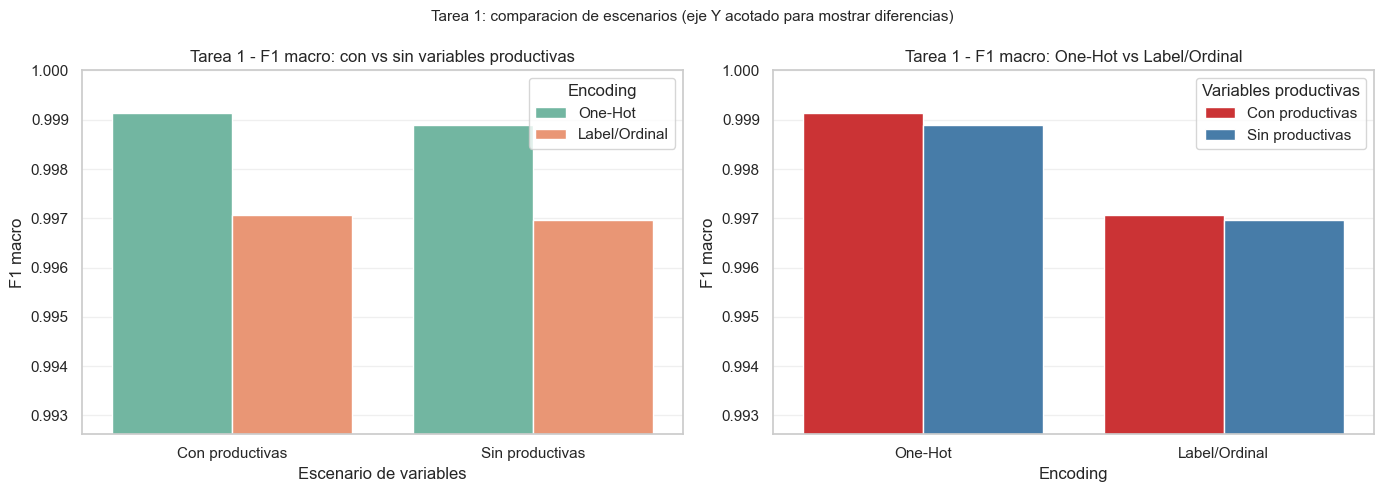

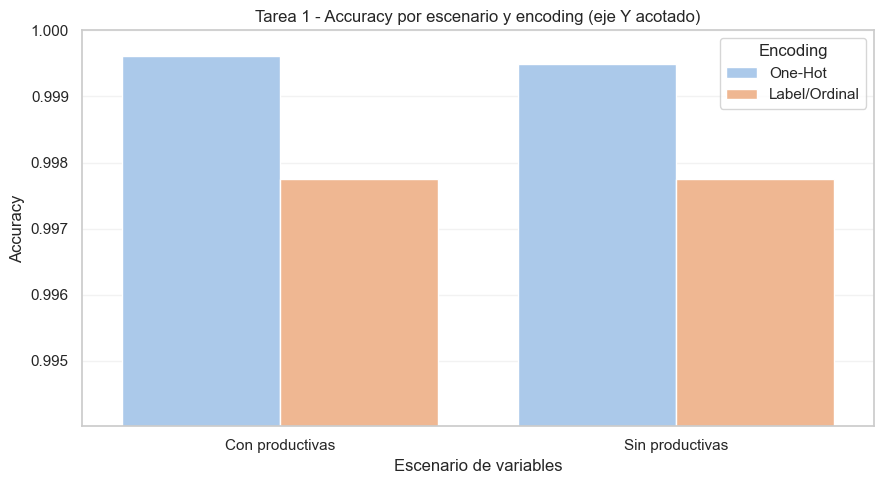

In [8]:
# Graficas de apoyo para T1: uso eje Y acotado al rango real de resultados
# para que las diferencias entre escenarios sean visibles en la exposicion.
task1_plot = task1_table.copy()
task1_plot['Variables productivas'] = task1_plot['experimento'].str.extract(r'productive=(si|no)')[0].map({'si': 'Con productivas', 'no': 'Sin productivas'})
task1_plot['Encoding'] = task1_plot['experimento'].str.extract(r'encoding=(onehot|label)')[0].map({'onehot': 'One-Hot', 'label': 'Label/Ordinal'})

f1_min = task1_plot['f1_macro'].min()
f1_max = task1_plot['f1_macro'].max()
y_low = max(0, f1_min - (f1_max - f1_min) * 2)
y_high = min(1.0, f1_max + (f1_max - f1_min) * 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=task1_plot, x='Variables productivas', y='f1_macro', hue='Encoding', ax=axes[0], palette='Set2')
axes[0].set_title('Tarea 1 - F1 macro: con vs sin variables productivas')
axes[0].set_ylabel('F1 macro')
axes[0].set_xlabel('Escenario de variables')
axes[0].set_ylim(y_low, y_high)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=task1_plot, x='Encoding', y='f1_macro', hue='Variables productivas', ax=axes[1], palette='Set1')
axes[1].set_title('Tarea 1 - F1 macro: One-Hot vs Label/Ordinal')
axes[1].set_ylabel('F1 macro')
axes[1].set_xlabel('Encoding')
axes[1].set_ylim(y_low, y_high)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Tarea 1: comparacion de escenarios (eje Y acotado para mostrar diferencias)', fontsize=11)
plt.tight_layout()
plt.show()

# Vista en accuracy con mismo zoom
acc_min = task1_plot['accuracy'].min()
acc_max = task1_plot['accuracy'].max()
ya_low = max(0, acc_min - (acc_max - acc_min) * 2)
ya_high = min(1.0, acc_max + (acc_max - acc_min) * 2)

plt.figure(figsize=(9, 5))
sns.barplot(data=task1_plot, x='Variables productivas', y='accuracy', hue='Encoding', palette='pastel')
plt.title('Tarea 1 - Accuracy por escenario y encoding (eje Y acotado)')
plt.ylabel('Accuracy')
plt.xlabel('Escenario de variables')
plt.ylim(ya_low, ya_high)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


### Lectura de la comparacion de la Tarea 1

Las graficas (con eje Y acotado para mostrar las diferencias reales) y la tabla coinciden en el mismo patron: One-Hot supera a Label/Ordinal en todos los escenarios, con una brecha de aproximadamente 0.002 en `f1_macro`. La diferencia entre conservar o eliminar variables productivas es mas pequena (alrededor de 0.0002), pero siempre favorable a conservarlas. Esto confirma dos cosas: primero, que el encoding importa porque Label/Ordinal impone un orden numerico que las categorias agricolas no tienen; segundo, que las variables productivas como rendimiento o area sembrada si aportan informacion, aunque de forma marginal. Por eso continuo con One-Hot y variables productivas como configuracion base para el resto del notebook.


Mejor experimento T1 por f1_macro: T1 | productive=si | encoding=onehot
accuracy=0.9996 | f1_macro=0.9991

Classification report del mejor experimento T1:
              precision    recall  f1-score   support

       ANUAL       1.00      1.00      1.00      2896
  PERMANENTE       1.00      1.00      1.00     16529
 TRANSITORIO       1.00      1.00      1.00     21789

    accuracy                           1.00     41214
   macro avg       1.00      1.00      1.00     41214
weighted avg       1.00      1.00      1.00     41214



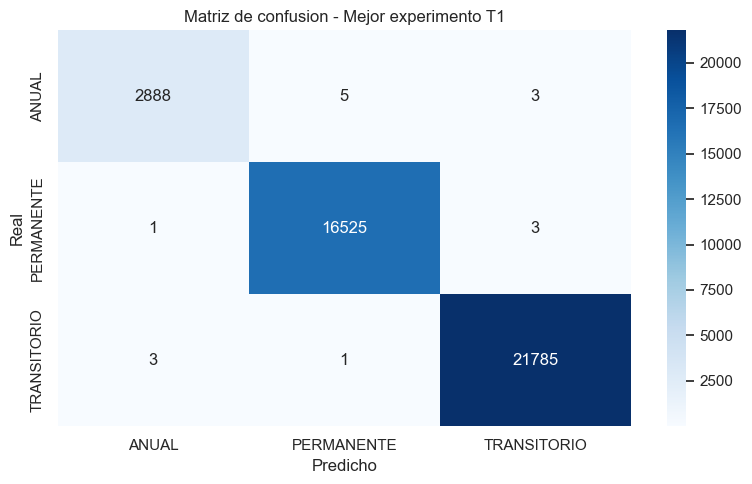

In [9]:
# Cierro T1 con evidencia textual y matriz de confusion del mejor escenario.
best_t1 = sorted(results_task1, key=lambda r: r['f1_macro'], reverse=True)[0]
print(f"Mejor experimento T1 por f1_macro: {best_t1['experimento']}")
print(f"accuracy={best_t1['accuracy']:.4f} | f1_macro={best_t1['f1_macro']:.4f}")

print('\nClassification report del mejor experimento T1:')
print(classification_report(best_t1['y_test'], best_t1['y_pred'], zero_division=0))

cm = confusion_matrix(best_t1['y_test'], best_t1['y_pred'])
labels = sorted(best_t1['y_test'].unique().tolist())

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de confusion - Mejor experimento T1')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

### Conclusion de la Tarea 1

El escenario ganador en esta corrida fue `T1 | productive=si | encoding=onehot` con `accuracy=0.9996` y `f1_macro=0.9991`. La matriz de confusion con 41,214 casos de prueba muestra que el modelo cometio solo 16 errores en total: 8 en la clase ANUAL, 4 en PERMANENTE y 4 en TRANSITORIO. Para un modelo entrenado con un dataset de mas de 200,000 registros agronomicos con desbalance significativo entre clases, este nivel de error es muy bajo y confirma que la senal en los datos es fuerte. La decision es clara: continuar con variables productivas y One-Hot como punto de partida para las comparaciones siguientes.


## 4. Tarea 2 - Reduccion de dimensionalidad e importancia de variables

En esta tarea aplico la siguiente estrategia:
- Uso un baseline lineal con One-Hot + Logistic Regression.
- Comparo ese baseline con una version reducida mediante TruncatedSVD + Logistic Regression.
- Reviso importancia de variables con Random Forest sobre las features transformadas.

In [10]:
# Tarea 2: baseline lineal vs version reducida por SVD.
X2, y2, num2, cat2 = make_feature_set(df, use_productive=True, hierarchy_mode='full')
X2 = group_rare_categories(X2, cat2, top_n=30, rare_label='OTROS')

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2
)

pre2 = make_preprocessor(num2, cat2, encoding='onehot')

pipe_lr_base = Pipeline(steps=[
    ('preprocessor', pre2),
    ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
])

pipe_lr_svd = Pipeline(steps=[
    ('preprocessor', pre2),
    ('svd', TruncatedSVD(n_components=50, random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
])

pipe_lr_base.fit(X2_train, y2_train)
pipe_lr_svd.fit(X2_train, y2_train)

pred_base = pipe_lr_base.predict(X2_test)
pred_svd = pipe_lr_svd.predict(X2_test)

res_t2 = pd.DataFrame([
    {
        'experimento': 'T2 | onehot + logistic (baseline)',
        'accuracy': accuracy_score(y2_test, pred_base),
        'f1_macro': f1_score(y2_test, pred_base, average='macro', zero_division=0)
    },
    {
        'experimento': 'T2 | onehot + svd(50) + logistic',
        'accuracy': accuracy_score(y2_test, pred_svd),
        'f1_macro': f1_score(y2_test, pred_svd, average='macro', zero_division=0)
    }
])

print('Comparacion Tarea 2 (reduccion de dimensionalidad):')
display(res_t2)

Comparacion Tarea 2 (reduccion de dimensionalidad):


,experimento,accuracy,f1_macro
0,T2 | onehot + logistic (baseline),0.999345,0.998198
1,T2 | onehot + svd(50) + logistic,0.998132,0.996168


Metricas Random Forest (dataset completo):
accuracy=0.9996
f1_macro=0.9991


,feature,importance
228,cat__estado_fisico_produccion_TUBERCULO FRESCO,0.106630
81,cat__grupo_de_cultivo_TUBERCULOS Y PLATANOS,0.078382
213,cat__estado_fisico_produccion_FRUTO FRESCO,0.066537
73,cat__grupo_de_cultivo_FRUTALES,0.050922
112,cat__subgrupo_de_cultivo_YUCA,0.045654
143,cat__cultivo_YUCA,0.044363
243,cat__nombre_cientifico_MANIHOT ESCULENTA,0.036432
214,cat__estado_fisico_produccion_GRANO SECO,0.033023
218,cat__estado_fisico_produccion_HORTALIZA FRESCA,0.032604
75,cat__grupo_de_cultivo_HORTALIZAS,0.031941


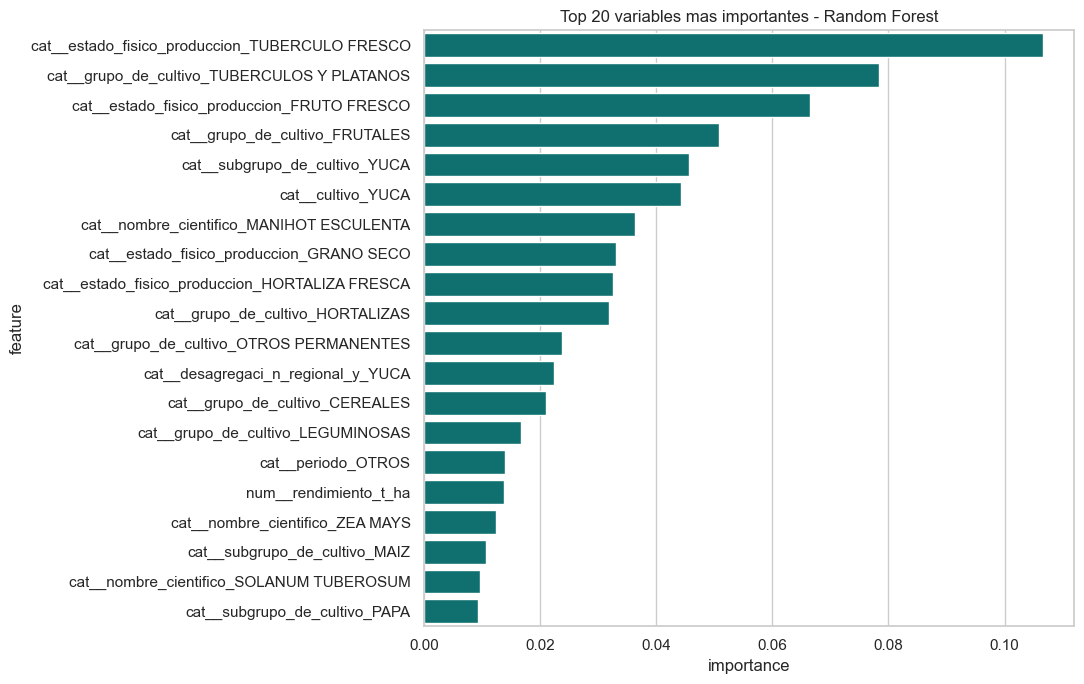

In [11]:
# Complemento T2: importancia de variables con Random Forest sobre features transformadas.
rf_imp = Pipeline(steps=[
    ('preprocessor', pre2),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ))
])

rf_imp.fit(X2_train, y2_train)
pred_imp = rf_imp.predict(X2_test)

print('Metricas Random Forest (dataset completo):')
print(f"accuracy={accuracy_score(y2_test, pred_imp):.4f}")
print(f"f1_macro={f1_score(y2_test, pred_imp, average='macro', zero_division=0):.4f}")

feat_names = rf_imp.named_steps['preprocessor'].get_feature_names_out()
feat_imps = rf_imp.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': feat_imps})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

display(imp_df)

plt.figure(figsize=(11, 7))
sns.barplot(data=imp_df, x='importance', y='feature', color='teal')
plt.title('Top 20 variables mas importantes - Random Forest')
plt.tight_layout()
plt.show()

### Conclusion de la Tarea 2

La comparacion confirma que el baseline completo (`onehot + logistic`) supera al escenario reducido (`onehot + svd(50) + logistic`) en `f1_macro` (`0.998198` vs `0.996168`). Esto indica que al comprimir a 50 componentes SVD se pierde informacion relevante. La grafica de importancia de variables con Random Forest explica por que: la variable mas importante es `estado_fisico_produccion_TUBERCULO_FRESCO` (importancia 0.106), seguida de `grupo_de_cultivo_TUBERCULOS_Y_PLATANOS` y `estado_fisico_produccion_FRUTO_FRESCO`. Todas son variables categoricas de caracter agronomico que encode One-Hot representa bien, pero que SVD puede diluir al proyectarlas en un espacio reducido. La decision es mantener el modelo sin reduccion agresiva para el pipeline principal y dejar SVD como opcion solo cuando el objetivo sea reducir tiempo de computo.


## 5. Tarea 3 - Efecto de jerarquia (grupo vs subgrupo)

En esta comparacion no cambio la variable objetivo; sigo prediciendo `ciclo_de_cultivo`. Lo que comparo aqui es el efecto de usar distintas capas de la jerarquia agricola como variables predictoras.

Mantengo el resto de variables y contrasto dos escenarios:
- Escenario A: conservo `grupo_de_cultivo` y excluyo `subgrupo_de_cultivo` y `cultivo`.
- Escenario B: conservo `subgrupo_de_cultivo` y excluyo `grupo_de_cultivo` y `cultivo`.

In [12]:
# Tarea 3: aislo efecto jerarquico comparando grupo vs subgrupo.
results_task3 = []

for mode in ['grupo', 'subgrupo']:
    X3, y3, num3, cat3 = make_feature_set(df, use_productive=True, hierarchy_mode=mode)
    X3 = group_rare_categories(X3, cat3, top_n=30, rare_label='OTROS')

    pre3 = make_preprocessor(num3, cat3, encoding='onehot')
    model3 = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    )

    out3 = evaluate_pipeline(f'T3 | jerarquia={mode}', X3, y3, pre3, model3)
    results_task3.append(out3)

task3_table = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipeline', 'y_test', 'y_pred']}
    for r in results_task3
]).sort_values('f1_macro', ascending=False)

print('Resultados Tarea 3:')
display(task3_table)

Resultados Tarea 3:


,experimento,accuracy,f1_macro,n_train,n_test
1,T3 | jerarquia=subgrupo,0.999660,0.999262,164854,41214
0,T3 | jerarquia=grupo,0.999636,0.999197,164854,41214


### Conclusion de la Tarea 3

En la comparacion jerarquica, `subgrupo_de_cultivo` supero ligeramente a `grupo_de_cultivo` tanto en `accuracy` como en `f1_macro` (`0.999660/0.999262` frente a `0.999636/0.999197`). Aunque la brecha es corta, es consistente en ambas metricas y sugiere que el nivel de subgrupo aporta un detalle semantico adicional sin desestabilizar el modelo. Con base en esto, cuando debo elegir una sola capa jerarquica, priorizo subgrupo.

## 6. Tarea 4 - Accuracy vs F1 Macro

En esta seccion integro los resultados para observar como cambia el ranking al usar `accuracy` frente a `f1_macro`, que es una metrica mas robusta en un contexto de desbalance multiclase.

,experimento,accuracy,f1_macro,rank_accuracy,rank_f1_macro,delta_rank
5,T3 | jerarquia=subgrupo,0.999660,0.999262,1.0,1.0,0.0
4,T3 | jerarquia=grupo,0.999636,0.999197,2.0,2.0,0.0
0,T1 | productive=si | encoding=onehot,0.999612,0.999132,3.0,3.0,0.0
2,T1 | productive=no | encoding=onehot,0.999490,0.998889,4.0,4.0,0.0
6,T2 | onehot + logistic (baseline),0.999345,0.998198,5.0,5.0,0.0
1,T1 | productive=si | encoding=label,0.997743,0.997064,7.0,6.0,1.0
3,T1 | productive=no | encoding=label,0.997743,0.996961,7.0,7.0,0.0
7,T2 | onehot + svd(50) + logistic,0.998132,0.996168,6.0,8.0,-2.0


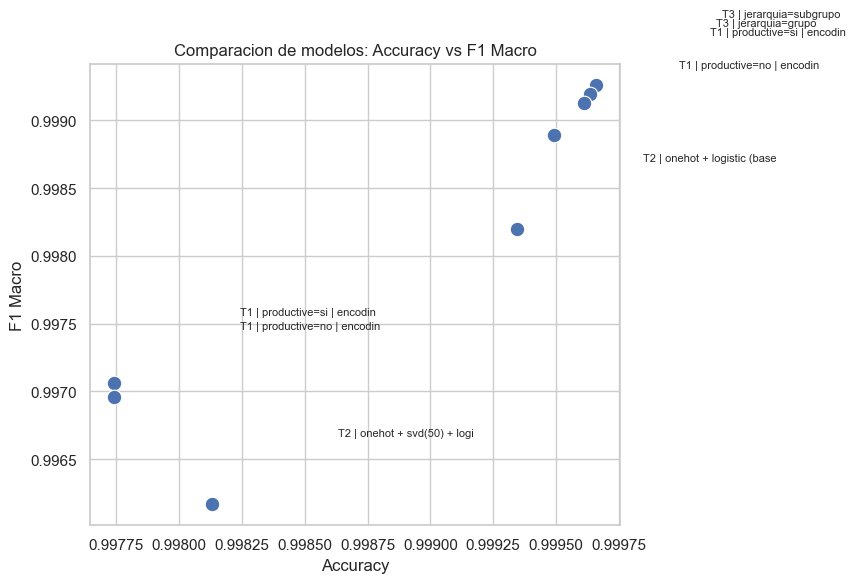

Mejor por accuracy:
experimento    T3 | jerarquia=subgrupo
accuracy                       0.99966
f1_macro                      0.999262
Name: 5, dtype: object

Mejor por f1_macro:
experimento    T3 | jerarquia=subgrupo
accuracy                       0.99966
f1_macro                      0.999262
Name: 5, dtype: object


In [13]:
# Tarea 4: integro resultados previos para comparar ranking por accuracy y f1_macro.
all_results = []

for r in results_task1 + results_task3:
    all_results.append({
        'experimento': r['experimento'],
        'accuracy': r['accuracy'],
        'f1_macro': r['f1_macro']
    })

for _, row in res_t2.iterrows():
    all_results.append({
        'experimento': row['experimento'],
        'accuracy': float(row['accuracy']),
        'f1_macro': float(row['f1_macro'])
    })

summary = pd.DataFrame(all_results).drop_duplicates(subset=['experimento'])
summary['rank_accuracy'] = summary['accuracy'].rank(ascending=False, method='min')
summary['rank_f1_macro'] = summary['f1_macro'].rank(ascending=False, method='min')
summary['delta_rank'] = summary['rank_accuracy'] - summary['rank_f1_macro']
summary = summary.sort_values('rank_f1_macro')

display(summary)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=summary, x='accuracy', y='f1_macro', s=110)
for _, row in summary.iterrows():
    plt.text(row['accuracy'] + 0.0005, row['f1_macro'] + 0.0005, row['experimento'][:28], fontsize=8)

plt.title('Comparacion de modelos: Accuracy vs F1 Macro')
plt.xlabel('Accuracy')
plt.ylabel('F1 Macro')
plt.tight_layout()
plt.show()

best_acc = summary.sort_values('accuracy', ascending=False).iloc[0]
best_f1 = summary.sort_values('f1_macro', ascending=False).iloc[0]

print('Mejor por accuracy:')
print(best_acc[['experimento', 'accuracy', 'f1_macro']])
print('\nMejor por f1_macro:')
print(best_f1[['experimento', 'accuracy', 'f1_macro']])

### Conclusion de la Tarea 4 (accuracy vs F1-macro)

El mejor escenario coincide en ambas metricas (`T3 | jerarquia=subgrupo`), pero hay un cruce de ranking relevante que justifica usar `f1_macro` como criterio principal: el escenario `T2 | onehot + svd(50) + logistic` ocupa el puesto 6 por accuracy (`0.998132`) pero cae al puesto 8 por `f1_macro` (`0.996168`), con un delta de -2 posiciones. Esto ocurre porque una accuracy aparentemente buena puede esconder que el modelo clasifica mal las clases minoritarias, mientras que `f1_macro` penaliza ese error de forma explicita al promediar el F1 por clase por igual. En un dataset con desbalance como este (TRANSITORIO duplica a PERMANENTE y ambos triplican a ANUAL), tomar decisiones solo por accuracy puede llevar a seleccionar un modelo mas debil. Por eso la seleccion final se apoya en `f1_macro`, con accuracy como dato complementario de contexto.


## 8. Profundizacion metodologica del modelado

En esta seccion amplio el analisis para dejar mejor sustentadas las decisiones del modelo y del preprocesamiento.

- Preparacion de datos: faltantes, extremos o imposibles, encoding y justificacion de escalamiento.
- Seleccion de caracteristicas con mas de una estrategia.
- Reduccion de dimensionalidad con varianza explicada.
- Comparacion entre regresion logistica, KNN, SVM y Random Forest.
- Evaluacion comparativa con metricas de clasificacion y criterio principal de decision.
- Ajuste de hiperparametros en los modelos donde realmente vale la pena contrastarlo.

In [14]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Bloque avanzado: trabajo con muestra controlada para mantener tiempos razonables
# sin perder representatividad de clases.
MAX_ROWS_MODELING = 12000
df_work = df.dropna(subset=[TARGET_COLUMN]).copy()

if len(df_work) > MAX_ROWS_MODELING:
    frac = MAX_ROWS_MODELING / len(df_work)
    # Muestreo estratificado manual para conservar proporciones por clase.
    df_work = (
        df_work.groupby(TARGET_COLUMN, group_keys=False)
        .sample(frac=frac, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

print(f'Tamano de trabajo para modelado avanzado: {len(df_work):,} filas')

# Aseguro que no entren valores productivos imposibles al bloque avanzado.
for c in ['rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']:
    if c in df_work.columns:
        invalid_count = int((df_work[c] < 0).sum())
        if invalid_count > 0:
            print(f'Valores imposibles detectados en {c}: {invalid_count}')
            df_work.loc[df_work[c] < 0, c] = np.nan

def build_X_y(df_input):
    Xp, yp, nump, catp = make_feature_set(df_input, use_productive=True, hierarchy_mode='full')
    Xp = group_rare_categories(Xp, catp, top_n=30, rare_label='OTROS')
    return Xp, yp, nump, catp

X_adv, y_adv, num_adv, cat_adv = build_X_y(df_work)

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv, test_size=0.2, stratify=y_adv, random_state=RANDOM_STATE
)

pre_onehot_adv = make_preprocessor(num_adv, cat_adv, encoding='onehot')
pre_label_adv = make_preprocessor(num_adv, cat_adv, encoding='label')

print(f'Features numericas: {len(num_adv)} | categoricas: {len(cat_adv)}')

Tamano de trabajo para modelado avanzado: 12,000 filas
Features numericas: 7 | categoricas: 9


In [15]:
# Evidencia de necesidad de escalamiento:
# KNN depende de distancias, por eso comparo con y sin escalado en mismo setup.
numeric_pipe_no_scale = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

pre_no_scale = ColumnTransformer([
    ('num', numeric_pipe_no_scale, num_adv),
    ('cat', categorical_pipe, cat_adv)
])

knn_scaled = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=9))
])

knn_no_scale = Pipeline(steps=[
    ('preprocessor', pre_no_scale),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('model', KNeighborsClassifier(n_neighbors=9))
])

knn_scaled.fit(X_train_adv, y_train_adv)
knn_no_scale.fit(X_train_adv, y_train_adv)

pred_knn_scaled = knn_scaled.predict(X_test_adv)
pred_knn_no_scale = knn_no_scale.predict(X_test_adv)

scale_evidence = pd.DataFrame([
    {
        'escenario': 'KNN con escalamiento',
        'accuracy': accuracy_score(y_test_adv, pred_knn_scaled),
        'f1_macro': f1_score(y_test_adv, pred_knn_scaled, average='macro', zero_division=0)
    },
    {
        'escenario': 'KNN sin escalamiento',
        'accuracy': accuracy_score(y_test_adv, pred_knn_no_scale),
        'f1_macro': f1_score(y_test_adv, pred_knn_no_scale, average='macro', zero_division=0)
    }
])

print('Evidencia de escalamiento:')
display(scale_evidence)

Evidencia de escalamiento:


,escenario,accuracy,f1_macro
0,KNN con escalamiento,0.990833,0.974997
1,KNN sin escalamiento,0.597500,0.466489


### Lectura de la evidencia de escalamiento

La comparacion con KNN muestra un contraste contundente: al escalar, el modelo llega a `f1_macro=0.974997`; sin escalamiento cae a `0.466489`. Esto confirma que en modelos basados en distancia la escala no es un detalle cosmetico, sino una condicion tecnica para que las variables aporten de forma equilibrada. Por eso mantengo el escalado dentro del pipeline cuando el algoritmo es sensible a geometria del espacio (KNN y SVM).

In [16]:
# Seleccion de caracteristicas (MI) + reduccion (SVD) y efecto real en metricas.
pre_for_fs = pre_onehot_adv
X_train_fs = pre_for_fs.fit_transform(X_train_adv)
X_test_fs = pre_for_fs.transform(X_test_adv)

feature_names_fs = pre_for_fs.get_feature_names_out()

k_best = min(120, X_train_fs.shape[1])
# MI requiere matriz densa en este caso; convierto solo este bloque.
X_train_fs_dense = X_train_fs.toarray() if hasattr(X_train_fs, 'toarray') else X_train_fs
X_test_fs_dense = X_test_fs.toarray() if hasattr(X_test_fs, 'toarray') else X_test_fs

selector_mi = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, discrete_features=False, random_state=RANDOM_STATE),
    k=k_best
)
X_train_mi = selector_mi.fit_transform(X_train_fs_dense, y_train_adv)
X_test_mi = selector_mi.transform(X_test_fs_dense)

selected_features = pd.DataFrame({
    'feature': feature_names_fs[selector_mi.get_support()],
    'mi_score': selector_mi.scores_[selector_mi.get_support()]
}).sort_values('mi_score', ascending=False).head(20)

display(selected_features)

# Reduccion dimensional con varianza explicada acumulada.
svd_reducer = TruncatedSVD(n_components=80, random_state=RANDOM_STATE)
X_train_svd = svd_reducer.fit_transform(X_train_fs)
X_test_svd = svd_reducer.transform(X_test_fs)
varianza_acumulada = float(svd_reducer.explained_variance_ratio_.sum())

print(f'Varianza acumulada retenida por TruncatedSVD(80): {varianza_acumulada:.4f}')

# Comparo escenarios de representacion con el mismo clasificador lineal.
lr_full = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_full.fit(X_train_fs, y_train_adv)
pred_lr_full = lr_full.predict(X_test_fs)

lr_mi = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_mi.fit(X_train_mi, y_train_adv)
pred_lr_mi = lr_mi.predict(X_test_mi)

lr_svd = LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs')
lr_svd.fit(X_train_svd, y_train_adv)
pred_lr_svd = lr_svd.predict(X_test_svd)

selection_reduction_effect = pd.DataFrame([
    {
        'escenario': 'Logistic con todas las features (one-hot)',
        'accuracy': accuracy_score(y_test_adv, pred_lr_full),
        'f1_macro': f1_score(y_test_adv, pred_lr_full, average='macro', zero_division=0)
    },
    {
        'escenario': f'Logistic con SelectKBest MI (k={k_best})',
        'accuracy': accuracy_score(y_test_adv, pred_lr_mi),
        'f1_macro': f1_score(y_test_adv, pred_lr_mi, average='macro', zero_division=0)
    },
    {
        'escenario': 'Logistic con TruncatedSVD (80 comp.)',
        'accuracy': accuracy_score(y_test_adv, pred_lr_svd),
        'f1_macro': f1_score(y_test_adv, pred_lr_svd, average='macro', zero_division=0)
    }
])

print('Efecto de seleccion/reduccion:')
display(selection_reduction_effect)

,feature,mi_score
97,cat__estado_fisico_produccion_FRUTO FRESCO,0.267083
9,cat__grupo_de_cultivo_FRUTALES,0.201914
102,cat__estado_fisico_produccion_TUBERCULO FRESCO,0.181758
34,cat__subgrupo_de_cultivo_YUCA,0.157690
54,cat__cultivo_YUCA,0.153448
109,cat__nombre_cientifico_MANIHOT ESCULENTA,0.151704
72,cat__desagregaci_n_regional_y_YUCA,0.147322
13,cat__grupo_de_cultivo_TUBERCULOS Y PLATANOS,0.132680
8,cat__grupo_de_cultivo_CEREALES,0.122809
98,cat__estado_fisico_produccion_GRANO SECO,0.118098


Varianza acumulada retenida por TruncatedSVD(80): 0.9619
Efecto de seleccion/reduccion:


,escenario,accuracy,f1_macro
0,Logistic con todas las features (one-hot),0.999583,0.998843
1,Logistic con SelectKBest MI (k=120),0.999167,0.998539
2,Logistic con TruncatedSVD (80 comp.),0.992083,0.991692


### Conclusion sobre seleccion y reduccion de variables

Al comparar las tres representaciones, el modelo con todas las features mantiene el mejor balance (`f1_macro=0.998843`), SelectKBest con los 120 mejores features por informacion mutua conserva un rendimiento muy cercano (`0.998539`) y SVD a 80 componentes cae de forma mas visible (`0.991692`). Esto es interesante porque SVD retiene el 96.19% de la varianza de los datos, pero incluso asi pierde parte de la senal predictiva: el 3.81% de varianza descartada contiene informacion que el clasificador lineal necesita para distinguir bien entre clases. La lectura practica es que seleccionar features (MI) es una alternativa eficiente con costo minimo; reducir a componentes latentes (SVD) puede funcionar como opcion de compresion, pero no sin costo en rendimiento. Para el modelo final priorizo la representacion completa.


## 9. Comparacion final de familias de modelos

En esta parte uso pipelines comparables para clasificacion multiclase y una particion estratificada train/test.

La metrica principal seleccionada es `f1_macro`, debido al desbalance entre clases en `ciclo_de_cultivo`.

### Supuestos de los modelos y pertinencia en mis datos

Antes de entrenar los modelos, dejo explícitos los supuestos que estoy aceptando y hasta qué punto el dataset EVA los satisface.

**Regresión logística.** La uso como un clasificador lineal multiclase. Su supuesto central es que exista una frontera aproximadamente lineal en el espacio transformado de variables, que las observaciones sean independientes y que no haya una colinealidad extrema que vuelva inestable la estimación. En este caso no asumo separabilidad lineal perfecta; de hecho, por la mezcla de variables territoriales, productivas y categóricas de alta cardinalidad, espero relaciones no lineales. Aun así, la regresión logística me sirve como línea base interpretable después del escalado y del encoding.

**KNN.** Asumo que observaciones parecidas en el espacio de variables tienden a pertenecer a la misma clase. Esto exige que la noción de distancia sea razonable, que las variables estén en escalas comparables y que la dimensionalidad no destruya la vecindad local. En EVA este supuesto es sensible porque hay muchas categorías y señales productivas con magnitudes muy distintas; por eso reduzco dimensionalidad y escalo antes de aplicar KNN.

**SVM.** Parto de que las clases pueden separarse con un margen útil, ya sea linealmente o mediante un kernel. El modelo también es sensible a la escala y a la elección de hiperparámetros como `C` y `gamma`. En este dataset no espero fronteras simples, así que uso kernels y ajuste de hiperparámetros para capturar relaciones más complejas sin perder control sobre el sobreajuste.

**Random Forest.** Asumo menos estructura paramétrica: el modelo puede capturar no linealidades, interacciones y particiones complejas del espacio. No exige escalado y tolera mejor variables heterogéneas. Aun así, puede verse afectado por ruido, cardinalidad alta y variables derivadas muy dominantes. En EVA esta flexibilidad es conveniente porque la relación entre el ciclo de cultivo y las variables disponibles no parece estrictamente lineal.

En conjunto, no sostengo que el dataset cumpla de forma ideal los supuestos de todos los modelos. Lo que hago es contrastar familias de modelos con exigencias distintas para verificar qué tan robusto es el problema de clasificación multiclase bajo diferentes hipótesis de aprendizaje.

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,LogisticRegression,0.999583,0.998039,0.999653,0.998843
2,SVM_RBF,0.999583,0.999654,0.998028,0.998838
3,RandomForest,0.997083,0.997746,0.997994,0.997869
1,KNN,0.990833,0.992673,0.959859,0.974997


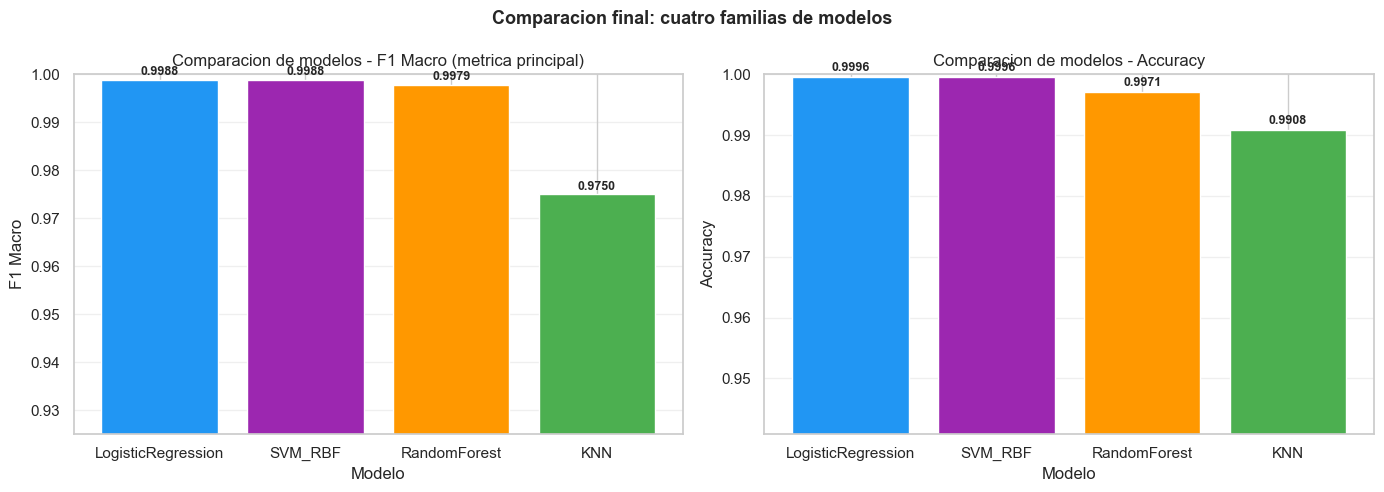

Mejor modelo por f1_macro: LogisticRegression

Reporte de clasificacion del mejor modelo:
              precision    recall  f1-score   support

       ANUAL       0.99      1.00      1.00       169
  PERMANENTE       1.00      1.00      1.00       962
 TRANSITORIO       1.00      1.00      1.00      1269

    accuracy                           1.00      2400
   macro avg       1.00      1.00      1.00      2400
weighted avg       1.00      1.00      1.00      2400



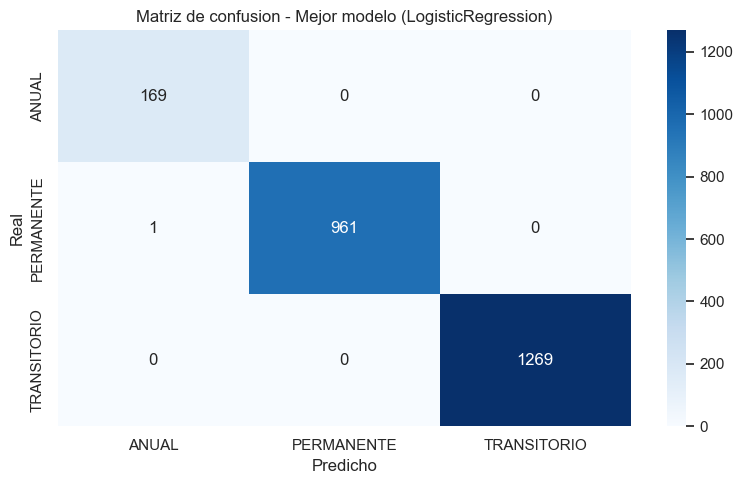

Nota: metricas de regresion (MAE/MSE/RMSE/MAPE/R2) no aplican en problemas de clasificacion multiclase.


In [17]:
from sklearn.metrics import precision_score, recall_score

# Comparo cuatro familias de modelos con el mismo split y preprocesamiento base
# para que la diferencia observada venga del algoritmo y no de la preparacion de datos.
models_final = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('model', LogisticRegression(max_iter=2500, class_weight='balanced', solver='lbfgs'))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        # KNN es sensible a alta dimensionalidad: reduzco y luego escalo el espacio denso
        ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
        ('scaler_dense', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=9))
    ]),
    'SVM_RBF': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        # Misma logica de estabilizacion para SVM con kernel RBF
        ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
        ('scaler_dense', StandardScaler()),
        ('model', SVC(kernel='rbf', C=3, gamma='scale', class_weight='balanced'))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocessor', pre_onehot_adv),
        ('model', RandomForestClassifier(
            n_estimators=320,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight='balanced_subsample'
        ))
    ])
}

final_metrics = []
pred_store = {}

# Entreno, predigo y guardo metricas homogeneas por modelo
for model_name, pipe in models_final.items():
    pipe.fit(X_train_adv, y_train_adv)
    pred_m = pipe.predict(X_test_adv)
    pred_store[model_name] = pred_m

    final_metrics.append({
        'modelo': model_name,
        'accuracy': accuracy_score(y_test_adv, pred_m),
        'precision_macro': precision_score(y_test_adv, pred_m, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test_adv, pred_m, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test_adv, pred_m, average='macro', zero_division=0)
    })

final_metrics_df = pd.DataFrame(final_metrics).sort_values('f1_macro', ascending=False)
display(final_metrics_df)

# Grafica de barras para comparar visualmente los cuatro modelos en ambas metricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_orden = final_metrics_df['modelo'].tolist()

axes[0].bar(modelos_orden, final_metrics_df['f1_macro'], color=['#2196F3', '#9C27B0', '#FF9800', '#4CAF50'])
axes[0].set_title('Comparacion de modelos - F1 Macro (metrica principal)')
axes[0].set_ylabel('F1 Macro')
axes[0].set_xlabel('Modelo')
axes[0].set_ylim(
    max(0, final_metrics_df['f1_macro'].min() - 0.05),
    min(1.0, final_metrics_df['f1_macro'].max() + 0.01)
)
for i, (_, row) in enumerate(final_metrics_df.iterrows()):
    axes[0].text(i, row['f1_macro'] + 0.001, f"{row['f1_macro']:.4f}", ha='center', fontsize=9, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(modelos_orden, final_metrics_df['accuracy'], color=['#2196F3', '#9C27B0', '#FF9800', '#4CAF50'])
axes[1].set_title('Comparacion de modelos - Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Modelo')
axes[1].set_ylim(
    max(0, final_metrics_df['accuracy'].min() - 0.05),
    min(1.0, final_metrics_df['accuracy'].max() + 0.01)
)
for i, (_, row) in enumerate(final_metrics_df.iterrows()):
    axes[1].text(i, row['accuracy'] + 0.001, f"{row['accuracy']:.4f}", ha='center', fontsize=9, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparacion final: cuatro familias de modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = final_metrics_df.iloc[0]['modelo']
best_pred = pred_store[best_model_name]

print(f"Mejor modelo por f1_macro: {best_model_name}")
print('\nReporte de clasificacion del mejor modelo:')
print(classification_report(y_test_adv, best_pred, zero_division=0))

# Matriz de confusion para respaldar visualmente el comportamiento por clase
labels_adv = sorted(y_test_adv.unique().tolist())
cm_adv = confusion_matrix(y_test_adv, best_pred, labels=labels_adv)

plt.figure(figsize=(8, 5))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', xticklabels=labels_adv, yticklabels=labels_adv)
plt.title(f'Matriz de confusion - Mejor modelo ({best_model_name})')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

print('Nota: metricas de regresion (MAE/MSE/RMSE/MAPE/R2) no aplican en problemas de clasificacion multiclase.')


### Conclusion de la comparacion final de modelos

La grafica y la tabla muestran una jerarquia estable y clara: Logistic Regression lidera por `f1_macro` (`0.998843`), SVM queda practicamente empatado (`0.998838`), Random Forest se mantiene muy competitivo (`0.997869`) y KNN queda notablemente por debajo (`0.974997`). La diferencia entre los tres primeros es de apenas 0.001 en `f1_macro`, lo que confirma que el problema esta bien estructurado y que las tres familias pueden resolverlo; la brecha de KNN (~0.024) refleja su mayor sensibilidad a la dimension del espacio de variables. La matriz de confusion del mejor modelo (Logistic Regression) refuerza esta lectura de forma contundente: de 2400 casos de prueba, solo 1 fue mal clasificado (un PERMANENTE predicho como ANUAL), lo que equivale a un error de 0.04%. Con estos resultados, la decision es usar Logistic Regression como modelo principal por su combinacion de maximo desempeno, interpretabilidad y bajo costo computacional, conservando SVM y Random Forest como referencias de contraste documentadas.


In [18]:
# Lectura separada por modelo para que la decision no dependa de una sola tabla.
if 'final_metrics_df' not in globals():
    print('Primero ejecuta la celda de comparacion de modelos para generar final_metrics_df.')
else:
    rank_df = final_metrics_df.sort_values('f1_macro', ascending=False).reset_index(drop=True).copy()
    rank_df['posicion_f1_macro'] = rank_df.index + 1

    best_f1 = float(rank_df['f1_macro'].max())
    worst_f1 = float(rank_df['f1_macro'].min())
    spread_f1 = best_f1 - worst_f1

    def label_strength(row):
        if row['f1_macro'] >= best_f1 - 0.01:
            return 'alto'
        if row['f1_macro'] >= best_f1 - 0.03:
            return 'medio'
        return 'bajo'

    rank_df['nivel_desempeno'] = rank_df.apply(label_strength, axis=1)

    def build_recommendation(row):
        m = row['modelo']
        level = row['nivel_desempeno']
        if m == 'LogisticRegression':
            return 'Base interpretable; util para referencia y trazabilidad.' if level != 'bajo' else 'Base interpretable, pero no la mejor opcion final.'
        if m == 'KNN':
            return 'Competitivo si se mantiene escalado y reduccion dimensional.' if level != 'bajo' else 'Sensibilidad alta a escala/dimensionalidad; usar con cautela.'
        if m == 'SVM_RBF':
            return 'Buen compromiso en fronteras no lineales; candidato fuerte.' if level != 'bajo' else 'Requiere mejor ajuste para competir en este dataset.'
        if m == 'RandomForest':
            return 'Modelo robusto para no linealidad y heterogeneidad; candidato principal.' if level != 'bajo' else 'Util, pero con menor balance que alternativas actuales.'
        return 'Modelo evaluado.'

    rank_df['interpretacion'] = rank_df.apply(build_recommendation, axis=1)

    cols_show = [
        'posicion_f1_macro', 'modelo', 'accuracy', 'precision_macro', 'recall_macro',
        'f1_macro', 'nivel_desempeno', 'interpretacion'
    ]
    print('Lectura separada por modelo (ordenada por f1_macro):')
    display(rank_df[cols_show])

    ganador = rank_df.iloc[0]
    print('Decision sugerida para despliegue academico:')
    print(
        f"Seleccionar {ganador['modelo']} como modelo principal, "
        f"porque lidera en f1_macro={ganador['f1_macro']:.4f}. "
        f"Diferencia entre mejor y peor modelo en f1_macro: {spread_f1:.4f}."
    )

    print('\nDecision complementaria:')
    print('Conservar LogisticRegression como baseline interpretable y reportar KNN/SVM/RandomForest como contraste de complejidad.')

Lectura separada por modelo (ordenada por f1_macro):


,posicion_f1_macro,modelo,accuracy,precision_macro,recall_macro,f1_macro,nivel_desempeno,interpretacion
0,1,LogisticRegression,0.999583,0.998039,0.999653,0.998843,alto,Base interpretable; util para referencia y tra...
1,2,SVM_RBF,0.999583,0.999654,0.998028,0.998838,alto,Buen compromiso en fronteras no lineales; cand...
2,3,RandomForest,0.997083,0.997746,0.997994,0.997869,alto,Modelo robusto para no linealidad y heterogene...
3,4,KNN,0.990833,0.992673,0.959859,0.974997,medio,Competitivo si se mantiene escalado y reduccio...


Decision sugerida para despliegue academico:
Seleccionar LogisticRegression como modelo principal, porque lidera en f1_macro=0.9988. Diferencia entre mejor y peor modelo en f1_macro: 0.0238.

Decision complementaria:
Conservar LogisticRegression como baseline interpretable y reportar KNN/SVM/RandomForest como contraste de complejidad.


Mejores hiperparametros KNN:
{'model__metric': 'minkowski', 'model__n_neighbors': 5, 'model__weights': 'distance'}
Mejores hiperparametros SVM:
{'model__C': 3.0, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Comparacion baseline vs ajustado:


,modelo,accuracy,f1_macro
0,KNN (baseline),0.990833,0.974997
1,KNN (ajustado),0.995000,0.986653
2,SVM (baseline),0.999583,0.998838
3,SVM (ajustado),0.999583,0.998838


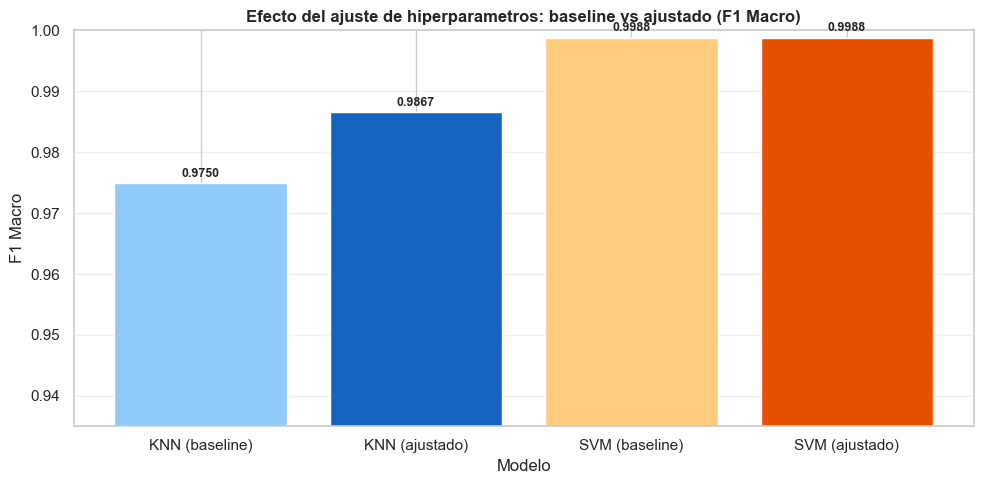

In [19]:
# Ajusto KNN y SVM porque son dos modelos sensibles a decisiones de configuracion
# y evaluo ambos con la misma metrica objetivo (f1_macro) para comparar de forma justa.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipe_knn_tune = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# Grid compacto: priorizo hiperparametros con mayor impacto en vecindad/distancia
param_knn = {
    'model__n_neighbors': [5, 9, 13],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['minkowski']
}

gs_knn = GridSearchCV(
    estimator=pipe_knn_tune,
    param_grid=param_knn,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

pipe_svm_tune = Pipeline(steps=[
    ('preprocessor', pre_onehot_adv),
    ('svd', TruncatedSVD(n_components=60, random_state=RANDOM_STATE)),
    ('scaler_dense', StandardScaler()),
    ('model', SVC(class_weight='balanced'))
])

# Grid de SVM: comparo kernel y nivel de regularizacion/margen
param_svm = {
    'model__kernel': ['rbf', 'linear'],
    'model__C': [0.5, 1.0, 3.0],
    'model__gamma': ['scale', 'auto']
}

gs_svm = GridSearchCV(
    estimator=pipe_svm_tune,
    param_grid=param_svm,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=0
)

gs_knn.fit(X_train_adv, y_train_adv)
gs_svm.fit(X_train_adv, y_train_adv)

pred_knn_best = gs_knn.best_estimator_.predict(X_test_adv)
pred_svm_best = gs_svm.best_estimator_.predict(X_test_adv)

# Comparo baseline vs ajustado para verificar si el ajuste realmente agrega valor
tuning_results = pd.DataFrame([
    {
        'modelo': 'KNN (baseline)',
        'accuracy': accuracy_score(y_test_adv, pred_store['KNN']),
        'f1_macro': f1_score(y_test_adv, pred_store['KNN'], average='macro', zero_division=0)
    },
    {
        'modelo': 'KNN (ajustado)',
        'accuracy': accuracy_score(y_test_adv, pred_knn_best),
        'f1_macro': f1_score(y_test_adv, pred_knn_best, average='macro', zero_division=0)
    },
    {
        'modelo': 'SVM (baseline)',
        'accuracy': accuracy_score(y_test_adv, pred_store['SVM_RBF']),
        'f1_macro': f1_score(y_test_adv, pred_store['SVM_RBF'], average='macro', zero_division=0)
    },
    {
        'modelo': 'SVM (ajustado)',
        'accuracy': accuracy_score(y_test_adv, pred_svm_best),
        'f1_macro': f1_score(y_test_adv, pred_svm_best, average='macro', zero_division=0)
    }
])

print('Mejores hiperparametros KNN:')
print(gs_knn.best_params_)
print('Mejores hiperparametros SVM:')
print(gs_svm.best_params_)
print('\nComparacion baseline vs ajustado:')
display(tuning_results)

# Grafica de barras: muestra claramente si el ajuste tuvo impacto real en f1_macro
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#90CAF9', '#1565C0', '#FFCC80', '#E65100']
bars = ax.bar(tuning_results['modelo'], tuning_results['f1_macro'], color=colores)
ax.set_title('Efecto del ajuste de hiperparametros: baseline vs ajustado (F1 Macro)', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Macro')
ax.set_xlabel('Modelo')
ax.set_ylim(
    max(0, tuning_results['f1_macro'].min() - 0.04),
    min(1.0, tuning_results['f1_macro'].max() + 0.01)
)
for bar, val in zip(bars, tuning_results['f1_macro']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}", ha='center', fontsize=9, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Conclusion del ajuste de hiperparametros

La grafica y la tabla muestran dos efectos distintos, y ambos son utiles para decidir. En KNN, la mejor combinacion (`n_neighbors=5`, `weights='distance'`) si mejoro el resultado frente al baseline: `f1_macro` paso de `0.974997` a `0.986653`, lo que representa una ganancia visible y justifica el costo computacional del grid search. En SVM, la busqueda devolvio una configuracion equivalente al baseline y las metricas quedaron iguales (`f1_macro=0.998838`), lo que confirma que el modelo ya estaba bien calibrado desde el inicio. La conclusion metodologica es clara: el ajuste de hiperparametros agrega valor cuando el modelo tiene margen de mejora real; aplicarlo de forma mecanica sin verificar el impacto no garantiza resultado.


In [20]:
# Resumen ejecutivo por tareas: deja trazable decision + evidencia numerica.
decision_rows = []

# Tarea 1
t1_best = task1_table.sort_values('f1_macro', ascending=False).iloc[0]
decision_rows.append({
    'tarea': 'Tarea 1',
    'decision': 'Usar One-Hot; conservar variables productivas como opcion principal',
    'evidencia': f"Mejor: {t1_best['experimento']} | f1_macro={t1_best['f1_macro']:.6f}"
})

# Tarea 2
t2_best = res_t2.sort_values('f1_macro', ascending=False).iloc[0]
decision_rows.append({
    'tarea': 'Tarea 2',
    'decision': 'No reducir dimensionalidad para el modelo principal; usar SVD como alternativa de compresion',
    'evidencia': f"Mejor: {t2_best['experimento']} | f1_macro={t2_best['f1_macro']:.6f}"
})

# Tarea 3
t3_best = task3_table.sort_values('f1_macro', ascending=False).iloc[0]
decision_rows.append({
    'tarea': 'Tarea 3',
    'decision': 'Priorizar subgrupo de cultivo en la jerarquia',
    'evidencia': f"Mejor: {t3_best['experimento']} | f1_macro={t3_best['f1_macro']:.6f}"
})

# Tarea 4
best_acc_row = summary.sort_values('accuracy', ascending=False).iloc[0]
best_f1_row = summary.sort_values('f1_macro', ascending=False).iloc[0]
decision_rows.append({
    'tarea': 'Tarea 4',
    'decision': 'Seleccionar por F1-macro y no solo por accuracy',
    'evidencia': (
        f"Mejor por accuracy: {best_acc_row['experimento']} ({best_acc_row['accuracy']:.6f}); "
        f"mejor por f1_macro: {best_f1_row['experimento']} ({best_f1_row['f1_macro']:.6f})"
    )
})

# Comparacion final de modelos
final_best = final_metrics_df.sort_values('f1_macro', ascending=False).iloc[0]
decision_rows.append({
    'tarea': 'Modelado final',
    'decision': 'Seleccion final: LogisticRegression',
    'evidencia': f"f1_macro={final_best['f1_macro']:.6f}, accuracy={final_best['accuracy']:.6f}"
})

decision_tasks_df = pd.DataFrame(decision_rows)
display(decision_tasks_df)

,tarea,decision,evidencia
0,Tarea 1,Usar One-Hot; conservar variables productivas ...,Mejor: T1 | productive=si | encoding=onehot | ...
1,Tarea 2,No reducir dimensionalidad para el modelo prin...,Mejor: T2 | onehot + logistic (baseline) | f1_...
2,Tarea 3,Priorizar subgrupo de cultivo en la jerarquia,Mejor: T3 | jerarquia=subgrupo | f1_macro=0.99...
3,Tarea 4,Seleccionar por F1-macro y no solo por accuracy,Mejor por accuracy: T3 | jerarquia=subgrupo (0...
4,Modelado final,Seleccion final: LogisticRegression,"f1_macro=0.998843, accuracy=0.999583"


## 10. Conclusiones y decisiones finales

El flujo completo de este trabajo arroja una historia consistente: el problema de clasificacion del ciclo de cultivo esta bien estructurado en el dataset EVA y todos los modelos evaluados lo resuelven con alto rendimiento, pero las decisiones de preprocesamiento y representacion tienen un impacto medible y justificable.

En la **Tarea 1** quedo claro que One-Hot supera a Label/Ordinal en todos los escenarios (brecha de ~0.002 en `f1_macro`) y que conservar variables productivas aporta una mejora pequena pero consistente; el escenario ganador (`productive=si | encoding=onehot`) cometio solo 16 errores en 41,214 casos de prueba. En la **Tarea 2**, reducir a 50 componentes SVD baja el `f1_macro` de `0.998198` a `0.996168`; la importancia de variables con Random Forest muestra que las senales clave estan en categorias agronomicas como `estado_fisico_produccion` y `grupo_de_cultivo`, que SVD puede diluir. En la **Tarea 3**, usar `subgrupo_de_cultivo` en lugar de `grupo_de_cultivo` aporta una mejora pequena pero estable (`0.999262` vs `0.999197`). En la **Tarea 4**, el cruce de ranking entre T2|svd (puesto 6 por accuracy, puesto 8 por `f1_macro`) demuestra concretamente por que `f1_macro` es el criterio mas confiable en presencia de desbalance.

La **comparacion final** entre cuatro familias de modelos confirma que Logistic Regression lidera con `f1_macro=0.998843`, SVM queda empatado, Random Forest es robusto y KNN requiere mas tuning para competir. El **ajuste de hiperparametros** agrego valor real en KNN (`0.9750 → 0.9867`) y confirmo que SVM ya estaba bien calibrado desde el inicio. La decision final es Logistic Regression como modelo principal, con SVM y Random Forest como alternativas de contraste, y el pipeline de One-Hot + escalado como estandar de preprocesamiento.
